In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

def filter_horses(dataset):
    images = []
    for img, label in dataset:
        if label == 7: # 7 is for horse
            images.append(img)
    return images

train_images = filter_horses(train_dataset)
test_images = filter_horses(test_dataset)

print("Train horses: ", len(train_images))
print("Test horses: ", len(test_images))

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train horses:  5000
Test horses:  1000


In [4]:
def rgb_to_grayscale(img):
    r, g, b = img[0], img[1], img[2] # img shape: (3, H, W)
    gray = 0.299*r + 0.587*g + 0.114*b
    return gray.unsqueeze(0) # (1, H, W)

In [5]:
class ColorizationDataset(torch.utils.data.Dataset):
    def __init__(self, images):
        self.images = images

    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, index):
        color = self.images[index]
        gray = rgb_to_grayscale(color)
        return gray, color

In [6]:
train_data = ColorizationDataset(train_images)
test_data = ColorizationDataset(test_images)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)

In [7]:
class ColorizationCNN(nn.Module):
    def __init__(self):
        super(ColorizationCNN, self).__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 3, 3, padding=1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.net(x)

In [8]:
def train_model(epochs):
    model = ColorizationCNN().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    losses = []
    for epoch in range(epochs):
        epoch_loss = 0

        for gray, color in train_loader:
            gray, color = gray.to(device), color.to(device)

            output = model(gray)
            loss = criterion(output, color)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")
    return model, losses

In [9]:
epoch_settings = [10, 30, 50]
trained_models = {}
loss_history = {}

for e in epoch_settings:
    print(f"\nTraining for {e} epochs\n")
    model, losses = train_model(e)
    
    trained_models[e] = model
    loss_history[e] = losses


Training for 10 epochs

Epoch [1/10], Loss: 0.0162
Epoch [2/10], Loss: 0.0051
Epoch [3/10], Loss: 0.0045
Epoch [4/10], Loss: 0.0044
Epoch [5/10], Loss: 0.0043
Epoch [6/10], Loss: 0.0042
Epoch [7/10], Loss: 0.0042
Epoch [8/10], Loss: 0.0042
Epoch [9/10], Loss: 0.0042
Epoch [10/10], Loss: 0.0041

Training for 30 epochs

Epoch [1/30], Loss: 0.0142
Epoch [2/30], Loss: 0.0048
Epoch [3/30], Loss: 0.0044
Epoch [4/30], Loss: 0.0043
Epoch [5/30], Loss: 0.0043
Epoch [6/30], Loss: 0.0042
Epoch [7/30], Loss: 0.0042
Epoch [8/30], Loss: 0.0041
Epoch [9/30], Loss: 0.0041
Epoch [10/30], Loss: 0.0041
Epoch [11/30], Loss: 0.0040
Epoch [12/30], Loss: 0.0041
Epoch [13/30], Loss: 0.0041
Epoch [14/30], Loss: 0.0040
Epoch [15/30], Loss: 0.0040
Epoch [16/30], Loss: 0.0040
Epoch [17/30], Loss: 0.0040
Epoch [18/30], Loss: 0.0040
Epoch [19/30], Loss: 0.0040
Epoch [20/30], Loss: 0.0040
Epoch [21/30], Loss: 0.0040
Epoch [22/30], Loss: 0.0039
Epoch [23/30], Loss: 0.0040
Epoch [24/30], Loss: 0.0039
Epoch [25/30], L

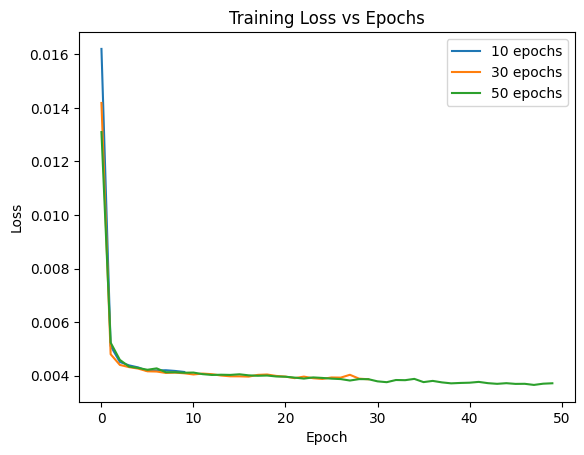

In [10]:
for e in epoch_settings:
    plt.plot(loss_history[e], label=f"{e} epochs")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Loss vs Epochs")
plt.show()

In [11]:
def show_images(model):
    model.eval()

    gray, color = next(iter(test_loader))
    gray, color = gray.to(device), color.to(device)

    with torch.no_grad():
        output = model(gray)

    gray = gray.cpu()
    color = color.cpu()
    output = output.cpu()

    for i in range(5):
        plt.figure(figsize=(10,3))

        # Gray
        plt.subplot(1,3,1)
        plt.title("Gray")
        plt.imshow(gray[i].squeeze(), cmap='gray')
        plt.axis('off')

        # Real
        plt.subplot(1,3,2)
        plt.title("Real")
        plt.imshow(np.transpose(color[i], (1,2,0)))
        plt.axis('off')

        # Predicted
        plt.subplot(1,3,3)
        plt.title("Predicted")
        plt.imshow(np.transpose(output[i], (1,2,0)))
        plt.axis('off')

        plt.show()


Results for 10 epochs



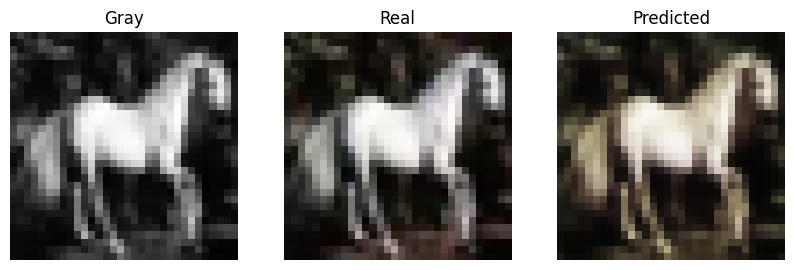

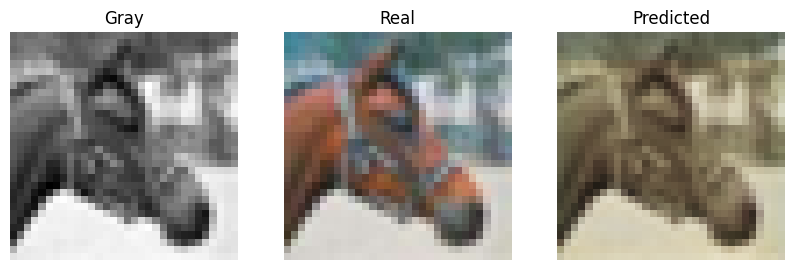

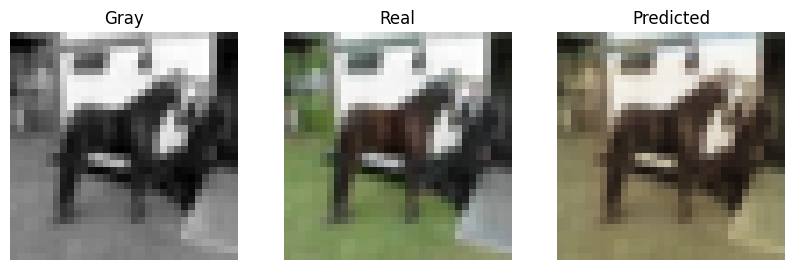

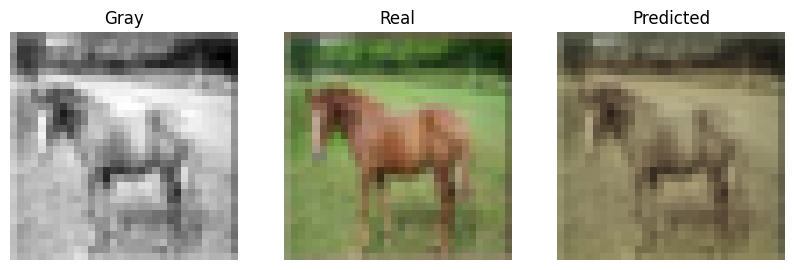

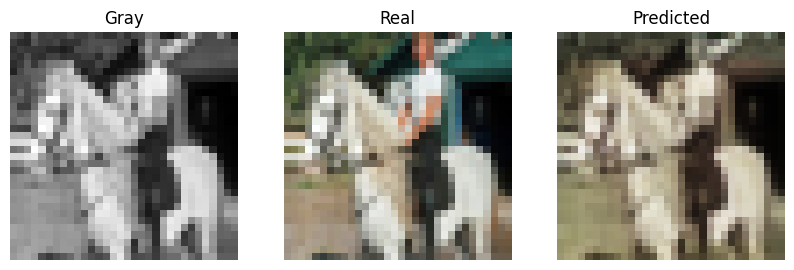


Results for 30 epochs



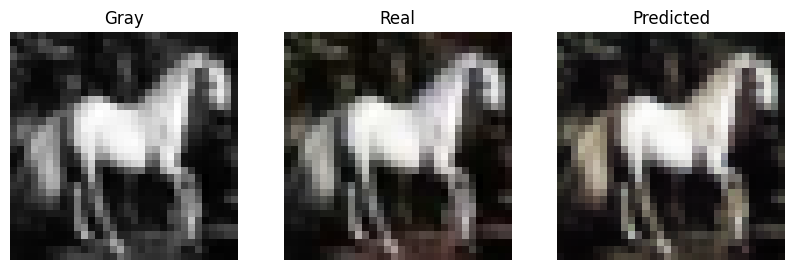

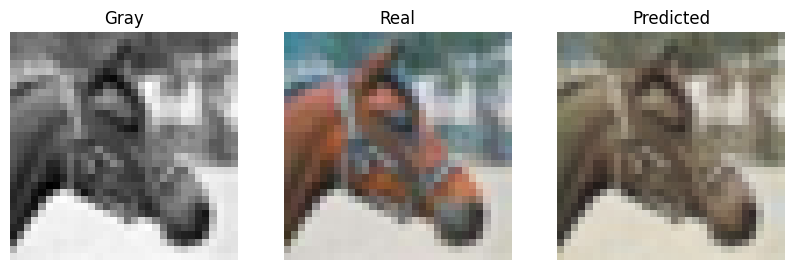

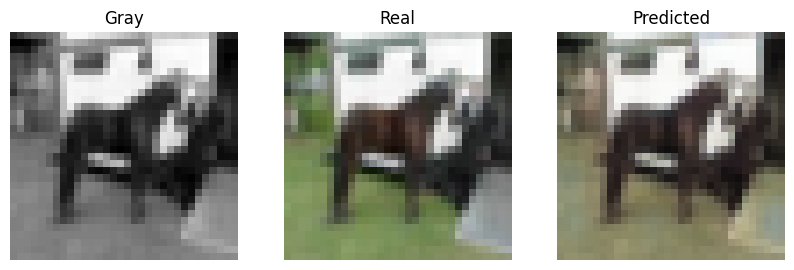

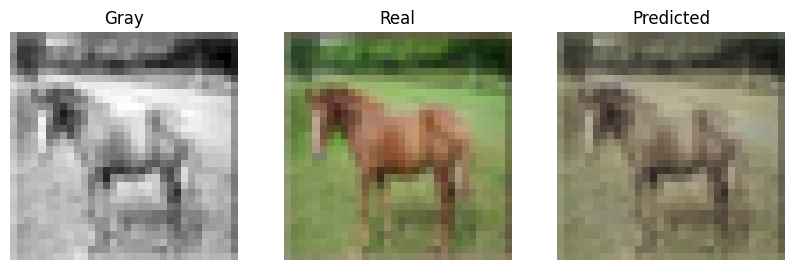

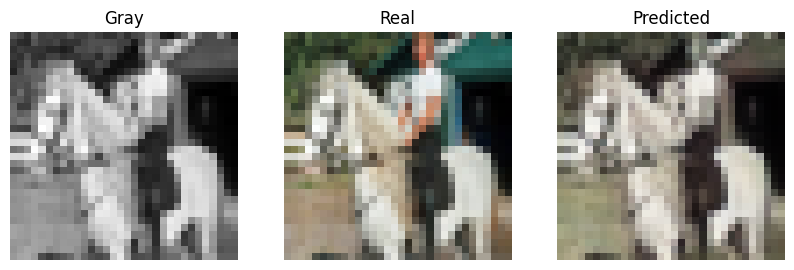


Results for 50 epochs



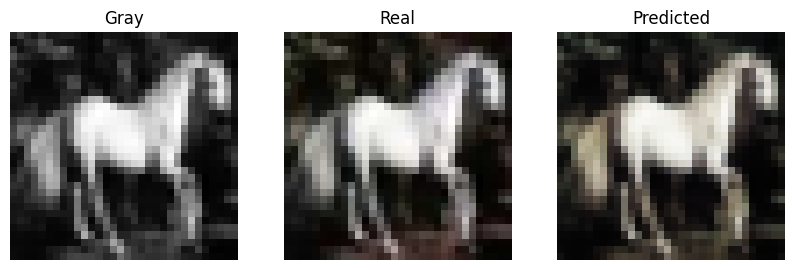

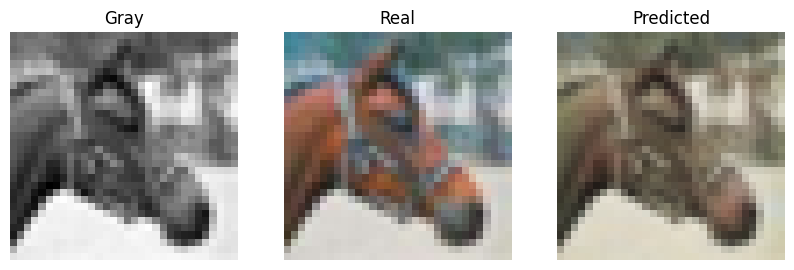

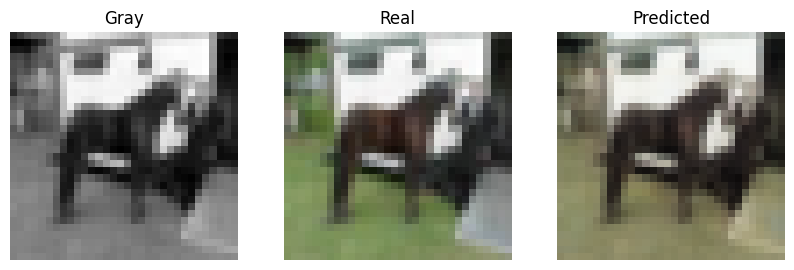

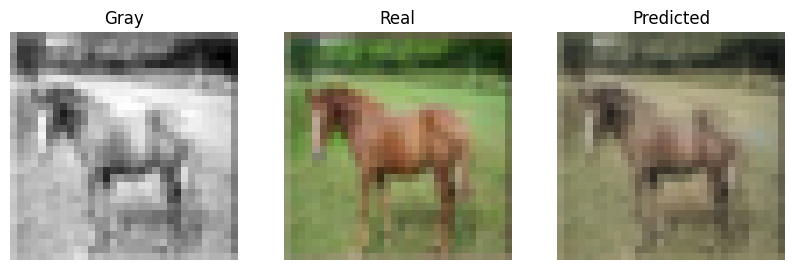

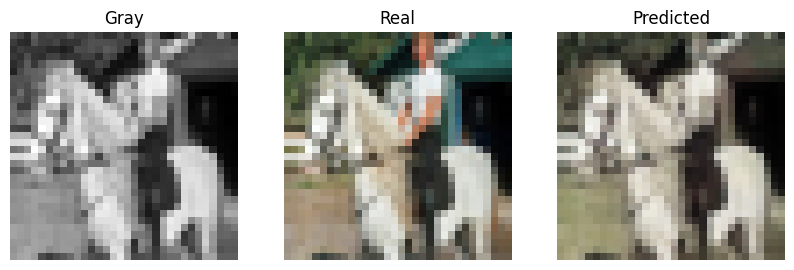

In [12]:
for e in epoch_settings:
    print(f"\nResults for {e} epochs\n")
    show_images(trained_models[e])